In [72]:
import pandas as pd
import numpy as np


In [73]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [74]:
df.shape

(5572, 5)

In [75]:
# Data cleaning
# EDA
# Text preprocessing
# Model building
# Evaluation
# Improvent depending on evaluation
# Website
# Deploy on Heroku

#### Data cleaning

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [77]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

In [78]:
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [79]:
# renaming the columns
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3351,ham,Call him and say you not coming today ok and t...
5503,ham,Perhaps * is much easy give your account ident...
1049,spam,18 days to Euro2004 kickoff! U will be kept in...
477,ham,Tension ah?what machi?any problem?
928,ham,Oh all have to come ah?


In [80]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [81]:
df['target']=encoder.fit_transform(df['target'])
df.head(10)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
5,1,FreeMsg Hey there darling it's been 3 week's n...
6,0,Even my brother is not like to speak with me. ...
7,0,As per your request 'Melle Melle (Oru Minnamin...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...


In [82]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [83]:
df.duplicated().sum()

np.int64(403)

In [84]:
df = df.drop_duplicates(keep='first')

In [85]:
df.duplicated().sum()

np.int64(0)

#### EDA

In [86]:
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [87]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x28b5d613280>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

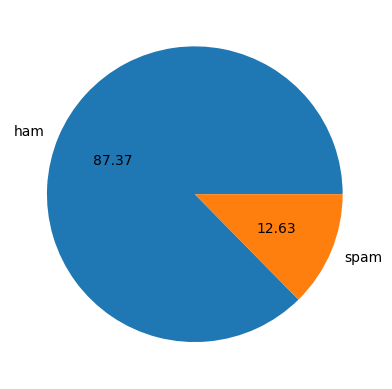

In [88]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")

In [89]:
# Data is imbalanced 

In [90]:
import nltk  # nltk = natural language tool kit
nltk.download('punkt')


[nltk_data] Downloading package punkt to C:\Users\Tanvir
[nltk_data]     Ishrak\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [91]:
df['num_characters']= df['text'].apply(len)
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [92]:
# num of words
# df['text'].apply(lambda x: nltk.word_tokenize(x))
df['num_words']= df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head(5)

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,23
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [93]:
df['num_sentences']= df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head(5)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,23,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [94]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.286129,1.961308
std,58.236293,13.226400,1.432583
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,219.000000,38.000000


In [95]:
# ham
df[df['target']==0][['num_characters','num_words','num_sentences']].describe() 

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,16.957484,1.815545
std,56.358207,13.394052,1.364098
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,219.000000,38.000000


In [96]:
# spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe() 

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.474732,2.969372
std,30.137753,6.893007,1.488910
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,44.000000,9.000000


In [97]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

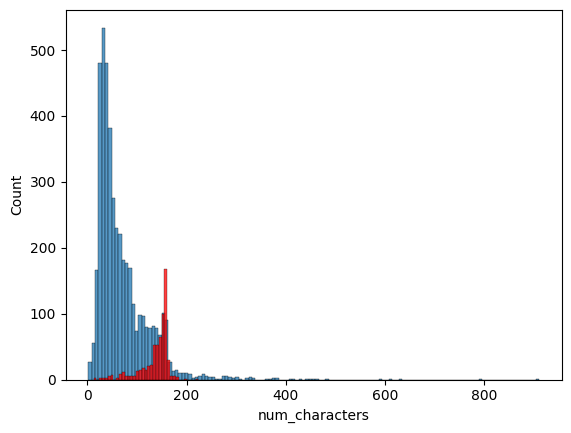

In [98]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

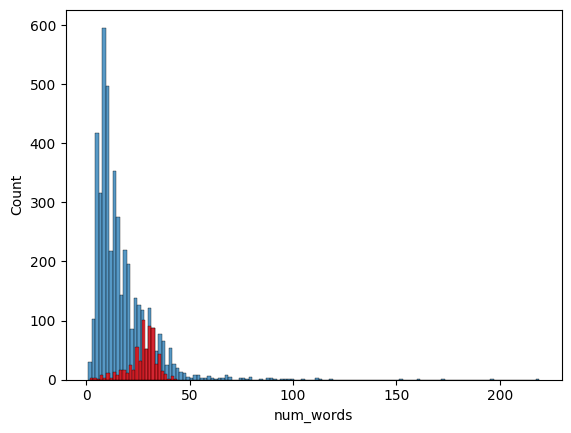

In [99]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

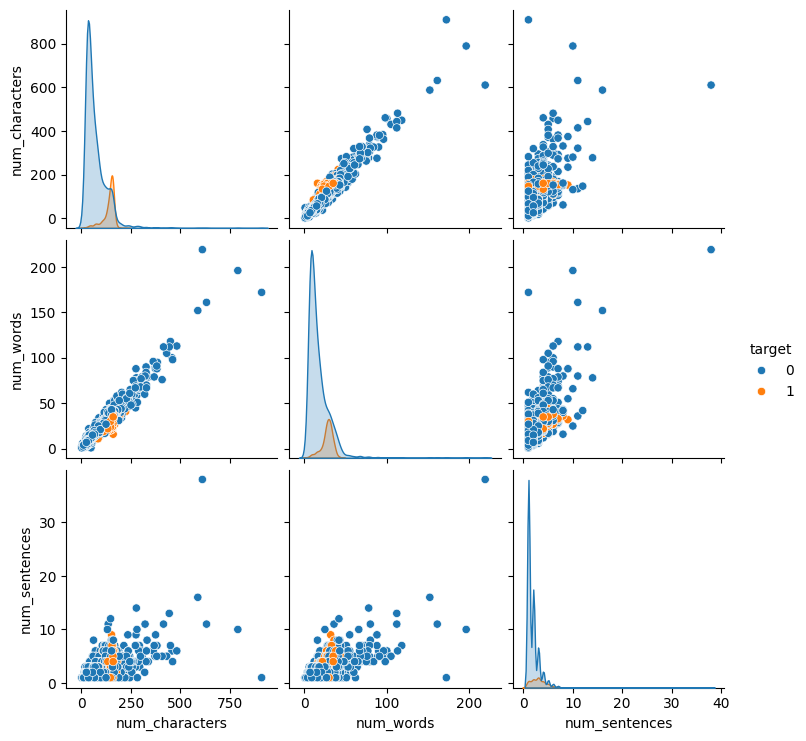

In [100]:
sns.pairplot(df, hue='target')

<Axes: >

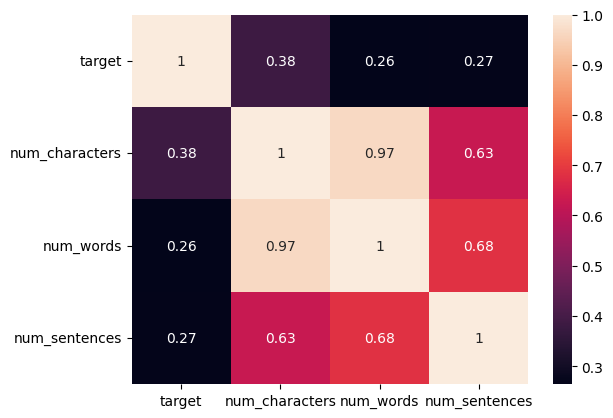

In [101]:
sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(), annot=True)

#### Data preprocessing

In [102]:
# lower case
# tokenization
# Removing Special characters
# removing stop words and punctiation
# stemming

In [103]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')

import string
string.punctuation

from nltk.stem.porter import PorterStemmer  # brings every wort to it's base form
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to C:\Users\Tanvir
[nltk_data]     Ishrak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [104]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():  # is alpha numeric
            y.append(i)
    
    text = y[:]  # data cloning
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
               
    return " ".join(y)

In [105]:
# transform_text('hello THeerw@# ishrak, how are you isr')
transform_text('i loved the youtube #@lecture on Machine Learning. How about you?')

'love youtub lectur machin learn'

In [106]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,23,2,go jurong point avail bugi n great world la e ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [107]:
from wordcloud import WordCloud
wc = WordCloud(width=500 , height=500,min_font_size=10 , background_color='white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

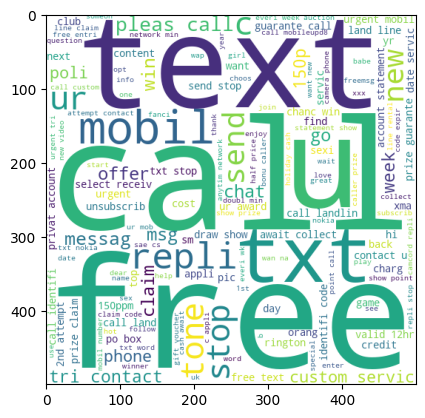

In [108]:
plt.Figure(figsize=(12,6))
plt.imshow(spam_wc)

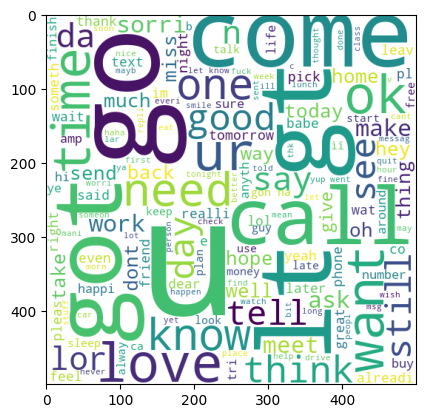

In [109]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))
plt.Figure(figsize=(12,6))
plt.imshow(ham_wc)

In [110]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

spam_corpus

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [111]:
len(spam_corpus)

9883

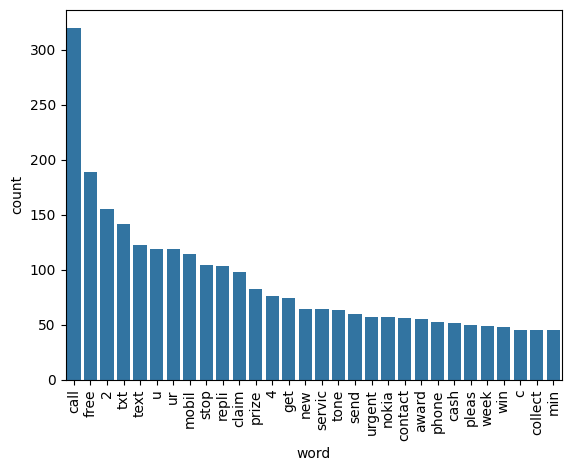

In [112]:
from collections import Counter
# sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],
#             pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
# # plt.xticks(rotation = 'vertical')
# create dataframe
common_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
common_df.columns = ['word', 'count']

# plot
sns.barplot(x='word', y='count', data=common_df)
plt.xticks(rotation='vertical')
plt.show()

In [113]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

ham_corpus

['go',
 'jurong',
 'point',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 '2',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'way',
 'u',
 'feel

In [114]:
len(ham_corpus)

34771

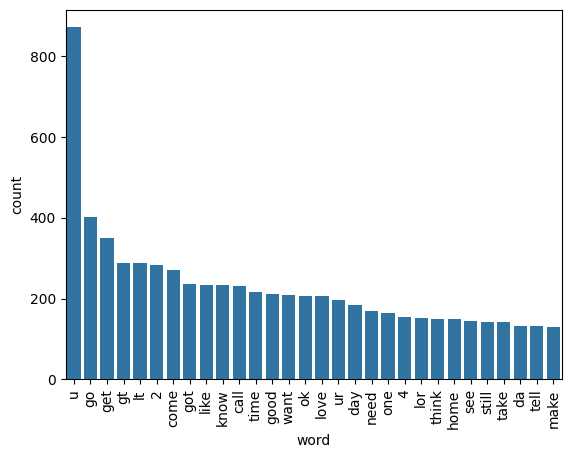

In [115]:
common_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
common_df.columns = ['word', 'count']

# plot
sns.barplot(x='word', y='count', data=common_df)
plt.xticks(rotation='vertical')
plt.show()

#### Model Building

In [120]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()

x = df['transformed_text']
y = df['target']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=3000)
# x = cv.fit_transform(df['transformed_text']).toarray()
# y = df['target'].values
x_train = tfidf.fit_transform(x_train)
y_train  = tfidf.transform(x_test)
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# x = scaler.fit_transform(x)

# appending the num_character col to x
# x = np.hstack((x,df['num_characters'].values.reshape(-1,1)))




In [121]:
from sklearn.naive_bayes import GaussianNB , MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [123]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

TypeError: Sparse data was passed for y, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

In [ ]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9729206963249516
[[885   4]
 [ 24 121]]
0.968


In [ ]:
# MultinomialNB gives the heighest precision score so we gonna process this
#tfidf -->> MNB

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1' )
rfc = RandomForestClassifier(n_estimators=50, random_state=42)
abc = AdaBoostClassifier(n_estimators=50, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42)
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=42)
xgb = XGBClassifier(n_estimators = 50, random_state=42)

In [ ]:

clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf, x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    return accuracy, precision

In [ ]:
accuracy_score_list = []
precision_score_list = []

for name,clf in clfs.items():
    current_accuracy , current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print('For :',name)
    print('Accuracy :', current_accuracy)
    print('Precision :', current_precision)
    
    accuracy_score_list.append(current_accuracy)
    precision_score_list.append(current_precision)


c:\Users\Tanvir Ishrak\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


For : SVC
Accuracy : 0.8597678916827853
Precision : 0.0
For : KN
Accuracy : 0.9323017408123792
Precision : 0.8
For : NB
Accuracy : 0.9400386847195358
Precision : 0.9882352941176471
For : DT
Accuracy : 0.9342359767891683
Precision : 0.8468468468468469
For : LR
Accuracy : 0.9535783365570599
Precision : 0.9008264462809917
For : RF
Accuracy : 0.9748549323017408
Precision : 0.9917355371900827
For : AdaBoost
Accuracy : 0.9381044487427466
Precision : 0.8648648648648649
For : BgC
Accuracy : 0.9613152804642167
Precision : 0.8620689655172413
For : ETC
Accuracy : 0.97678916827853
Precision : 0.9763779527559056
For : GBDT
Accuracy : 0.9506769825918762
Precision : 0.9433962264150944
For : xgb
Accuracy : 0.9709864603481625
Precision : 0.96


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_score_list,'Precision':precision_score_list}).sort_values('Precision',ascending=False)
performance_df

,Algorithm,Accuracy,Precision
5,RF,0.974855,0.991736
2,NB,0.940039,0.988235
8,ETC,0.976789,0.976378
10,xgb,0.970986,0.960000
9,GBDT,0.950677,0.943396
4,LR,0.953578,0.900826
6,AdaBoost,0.938104,0.864865
7,BgC,0.961315,0.862069
3,DT,0.934236,0.846847
1,KN,0.932302,0.800000


#### Model improve

In [ ]:
# 1. change the max_features parameters of IfIdf


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_score_list,'Precision_max_ft_3000':precision_score_list}).sort_values('Precision_max_ft_3000',ascending=False)


In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_score_list,'Precision_scaling':precision_score_list}).sort_values('Precision_scaling',ascending=False)


In [ ]:
new_df = performance_df.merge(temp_df,on='Algorithm')
new_df_scaled = new_df.merge(temp_df,on='Algorithm')
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_score_list,'Precision_num_chars':precision_score_list}).sort_values('Precision_num_chars',ascending=False)
new_df_scaled.merge(temp_df,on='Algorithm')


,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,RF,0.974855,0.991736,0.974855,0.991736,0.974855,0.991736,0.974855,0.991736
1,NB,0.940039,0.988235,0.940039,0.988235,0.940039,0.988235,0.940039,0.988235
2,ETC,0.976789,0.976378,0.976789,0.976378,0.976789,0.976378,0.976789,0.976378
3,xgb,0.970986,0.960000,0.970986,0.960000,0.970986,0.960000,0.970986,0.960000
4,GBDT,0.950677,0.943396,0.950677,0.943396,0.950677,0.943396,0.950677,0.943396
5,LR,0.953578,0.900826,0.953578,0.900826,0.953578,0.900826,0.953578,0.900826
6,AdaBoost,0.938104,0.864865,0.938104,0.864865,0.938104,0.864865,0.938104,0.864865
7,BgC,0.961315,0.862069,0.961315,0.862069,0.961315,0.862069,0.961315,0.862069
8,DT,0.934236,0.846847,0.934236,0.846847,0.934236,0.846847,0.934236,0.846847
9,KN,0.932302,0.800000,0.932302,0.800000,0.932302,0.800000,0.932302,0.800000


In [ ]:
## voting classifier

rf = RandomForestClassifier(n_estimators=50, random_state=42)
mnb = MultinomialNB()
ctc = ExtraTreesClassifier(n_estimators=50, random_state=42)

In [ ]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('rf',rf), ('nb', mnb),('et',etc)], voting='soft')

In [ ]:
voting.fit(x_train,y_train)

,estimators,"[('rf', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [ ]:

y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9700193423597679
Precision 1.0


In [ ]:
model = RandomForestClassifier()
model.fit(x_train,y_train)

import pickle 
pickle.dump(tfidf, open('vectorizer.pkl','wb'))
pickle.dump(model,open('model.pkl','wb'))

print('pickel made successfully')

pickel made successfully
